# Lag-only models — predicting daily change in Polymarket Trump probability

Three models trained exclusively on lagged Polymarket Trump probability:
1. Linear Regression
2. Random Forest
3. Neural Network (MLP)

**Target:** `Δ polymarket_trump_prob = prob(t) − prob(t−1)`  
**Features:** `polymarket_trump_prob` lagged 1–5 days (`prob_lag1` … `prob_lag5`)  
**Splits:** `get_test_split` + `get_cv_folds` from `Functions/data_splits.py`  
**Metrics:** MAE, RMSE, Directional Accuracy, R²

<!-- toc -->
## Contents
- [1. Setup](#1-setup)
- [2. Load data, create lag features & target](#2-load-data-create-lag-features-target)
- [3. Train/val/test split](#3-trainvaltest-split)
- [4. CV folds](#4-cv-folds)
- [5. Helper functions](#5-helper-functions)
- [6. Model 1 — Linear Regression](#6-model-1-linear-regression)
- [7. Model 2 — Random Forest](#7-model-2-random-forest)
- [8. Model 3 — Neural Network (MLP)](#8-model-3-neural-network-mlp)
- [9. Model comparison](#9-model-comparison)


## 1. Setup

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')

# Make Functions/ importable from Predictive/Basic/
sys.path.insert(0, '../../')
from Functions.data_splits import (
    get_cv_folds,
    get_test_split,
    print_fold_summary,
    validate_no_leakage,
)

RANDOM_STATE = 42
TEST_DAYS    = 14
N_SPLITS     = 3
GAP          = 1
N_LAGS       = 5   # number of lagged prob values used as features

## 2. Load data, create lag features & target

In [2]:
df_raw = pd.read_csv('../../Data/3_Gold/basetable.csv', parse_dates=['date'])
df_raw = df_raw.sort_values('date').reset_index(drop=True)

print(f"Rows: {len(df_raw)}  |  Date range: {df_raw['date'].min().date()} → {df_raw['date'].max().date()}")

# Build a clean working dataframe with only what we need
df = df_raw[['date', 'polymarket_trump_prob']].copy()

# Target: daily change in Trump probability
df['target'] = df['polymarket_trump_prob'].diff()

# Lag features: prob(t-1), prob(t-2), ..., prob(t-N_LAGS)
lag_cols = []
for k in range(1, N_LAGS + 1):
    col = f'prob_lag{k}'
    df[col] = df['polymarket_trump_prob'].shift(k)
    lag_cols.append(col)

# Drop rows with any NaN (first N_LAGS rows)
df = df.dropna().reset_index(drop=True)

print(f"\nFeatures ({len(lag_cols)}): {lag_cols}")
print(f"Clean rows: {len(df)}  ({df['date'].min().date()} → {df['date'].max().date()})")
print(f"\nTarget (daily Δ prob) stats:")
print(df['target'].describe().round(4))

Rows: 124  |  Date range: 2024-07-04 → 2024-11-04

Features (5): ['prob_lag1', 'prob_lag2', 'prob_lag3', 'prob_lag4', 'prob_lag5']
Clean rows: 119  (2024-07-09 → 2024-11-04)

Target (daily Δ prob) stats:
count    119.0000
mean      -0.0004
std        0.0178
min       -0.0600
25%       -0.0100
50%       -0.0005
75%        0.0090
max        0.0800
Name: target, dtype: float64


## 3. Train/val/test split

In [3]:
tv_idx, test_idx = get_test_split(df, test_days=TEST_DAYS)

df_tv   = df.iloc[tv_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_tv   = df_tv[lag_cols].values
y_tv   = df_tv['target'].values
X_test = df_test[lag_cols].values
y_test = df_test['target'].values

print(f"Train/val : {len(df_tv):>4} rows  ({df_tv['date'].min().date()} → {df_tv['date'].max().date()})")
print(f"Test      : {len(df_test):>4} rows  ({df_test['date'].min().date()} → {df_test['date'].max().date()})")

Train/val :  105 rows  (2024-07-09 → 2024-10-21)
Test      :   14 rows  (2024-10-22 → 2024-11-04)


## 4. CV folds

In [4]:
folds = get_cv_folds(df_tv, n_splits=N_SPLITS, gap=GAP, test_days=None)
print_fold_summary(df_tv, folds)

print("\nLeakage validation:")
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df_tv, gap=GAP)
    print(f"  Fold {i}: OK")

Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-09    2024-08-03       26    2024-08-05    2024-08-30      26
   2    2024-07-09    2024-08-29       52    2024-08-31    2024-09-25      26
   3    2024-07-09    2024-09-24       78    2024-09-26    2024-10-21      26

Leakage validation:
  Fold 1: OK
  Fold 2: OK
  Fold 3: OK


## 5. Helper functions

In [5]:
def directional_accuracy(y_true, y_pred):
    """Fraction of predictions with the correct direction (sign)."""
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))


def compute_metrics(y_true, y_pred):
    return {
        'MAE'          : mean_absolute_error(y_true, y_pred),
        'RMSE'         : np.sqrt(mean_squared_error(y_true, y_pred)),
        'Dir. Accuracy': directional_accuracy(y_true, y_pred),
        'R2'           : r2_score(y_true, y_pred),
    }


def cv_evaluate(model_factory, folds, X, y, scale=False):
    """
    Walk-forward CV. Scalers are fit on training folds only (no leakage).
    Returns a DataFrame with per-fold metrics plus Mean / Std rows.
    """
    records = []
    for i, (train_idx, val_idx) in enumerate(folds, 1):
        X_tr, y_tr   = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx],   y[val_idx]

        if scale:
            sc = StandardScaler()
            X_tr  = sc.fit_transform(X_tr)
            X_val = sc.transform(X_val)

        model = model_factory()
        model.fit(X_tr, y_tr)
        m = compute_metrics(y_val, model.predict(X_val))
        records.append({'Fold': i, **m})
        print(f"  Fold {i}: MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  "
              f"DA={m['Dir. Accuracy']:.3f}  R2={m['R2']:.4f}")

    agg  = pd.DataFrame(records).set_index('Fold')
    mean = agg.mean().rename('Mean')
    std  = agg.std().rename('Std')
    print(f"  ─ Mean ─  MAE={mean['MAE']:.4f}  RMSE={mean['RMSE']:.4f}  "
          f"DA={mean['Dir. Accuracy']:.3f}  R2={mean['R2']:.4f}")
    return pd.concat([agg, mean.to_frame().T, std.to_frame().T])


def final_eval(model_factory, X_tv, y_tv, X_test, y_test, scale=False):
    """Retrain on full train/val, evaluate on held-out test set."""
    if scale:
        sc = StandardScaler()
        X_tv_s   = sc.fit_transform(X_tv)
        X_test_s = sc.transform(X_test)
    else:
        X_tv_s, X_test_s = X_tv, X_test

    model = model_factory()
    model.fit(X_tv_s, y_tv)
    y_pred = model.predict(X_test_s)
    return model, y_pred, compute_metrics(y_test, y_pred)

## 6. Model 1 — Linear Regression

In [6]:
print("=== Linear Regression — CV ===")
lr_cv = cv_evaluate(
    model_factory=LinearRegression,
    folds=folds, X=X_tv, y=y_tv,
    scale=True,
)
lr_cv.round(4)

=== Linear Regression — CV ===
  Fold 1: MAE=0.0103  RMSE=0.0140  DA=0.385  R2=-0.1488
  Fold 2: MAE=0.0073  RMSE=0.0094  DA=0.615  R2=0.1185
  Fold 3: MAE=0.0130  RMSE=0.0173  DA=0.385  R2=-0.4167
  ─ Mean ─  MAE=0.0102  RMSE=0.0136  DA=0.462  R2=-0.1490


,MAE,RMSE,Dir. Accuracy,R2
1,0.0103,0.0140,0.3846,-0.1488
2,0.0073,0.0094,0.6154,0.1185
3,0.0130,0.0173,0.3846,-0.4167
Mean,0.0102,0.0136,0.4615,-0.1490
Std,0.0029,0.0040,0.1332,0.2676


In [7]:
lr_model, lr_pred, lr_test = final_eval(
    LinearRegression, X_tv, y_tv, X_test, y_test, scale=True
)
print("Linear Regression — Test set:")
for k, v in lr_test.items():
    print(f"  {k}: {v:.4f}")

Linear Regression — Test set:
  MAE: 0.0161
  RMSE: 0.0200
  Dir. Accuracy: 0.5714
  R2: 0.0206


## 7. Model 2 — Random Forest

In [8]:
rf_factory = lambda: RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("=== Random Forest — CV ===")
rf_cv = cv_evaluate(
    model_factory=rf_factory,
    folds=folds, X=X_tv, y=y_tv,
    scale=False,   # trees are scale-invariant
)
rf_cv.round(4)

=== Random Forest — CV ===


  Fold 1: MAE=0.0146  RMSE=0.0174  DA=0.538  R2=-0.7725
  Fold 2: MAE=0.0078  RMSE=0.0098  DA=0.538  R2=0.0480
  Fold 3: MAE=0.0151  RMSE=0.0209  DA=0.385  R2=-1.0724
  ─ Mean ─  MAE=0.0125  RMSE=0.0160  DA=0.487  R2=-0.5990


,MAE,RMSE,Dir. Accuracy,R2
1,0.0146,0.0174,0.5385,-0.7725
2,0.0078,0.0098,0.5385,0.0480
3,0.0151,0.0209,0.3846,-1.0724
Mean,0.0125,0.0160,0.4872,-0.5990
Std,0.0041,0.0057,0.0888,0.5800


In [9]:
rf_model, rf_pred, rf_test = final_eval(
    rf_factory, X_tv, y_tv, X_test, y_test, scale=False
)
print("Random Forest — Test set:")
for k, v in rf_test.items():
    print(f"  {k}: {v:.4f}")

Random Forest — Test set:
  MAE: 0.0166
  RMSE: 0.0199
  Dir. Accuracy: 0.5000
  R2: 0.0297


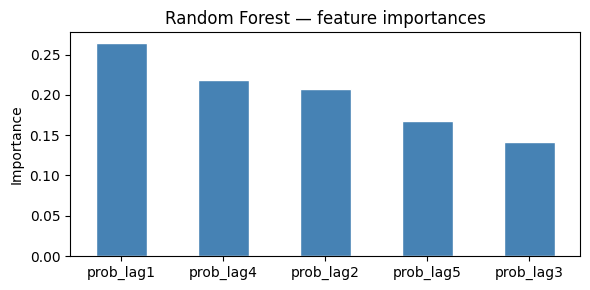

In [10]:
# Feature importances
fi = pd.Series(rf_model.feature_importances_, index=lag_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 3))
fi.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest — feature importances')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', labelrotation=0)
plt.tight_layout()
plt.show()

## 8. Model 3 — Neural Network (MLP)

In [11]:
nn_factory = lambda: MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
    random_state=RANDOM_STATE,
)

print("=== Neural Network (MLP) — CV ===")
nn_cv = cv_evaluate(
    model_factory=nn_factory,
    folds=folds, X=X_tv, y=y_tv,
    scale=True,
)
nn_cv.round(4)

=== Neural Network (MLP) — CV ===
  Fold 1: MAE=0.4485  RMSE=0.4635  DA=0.462  R2=-1262.1601
  Fold 2: MAE=0.0418  RMSE=0.0514  DA=0.615  R2=-25.3394
  Fold 3: MAE=0.0254  RMSE=0.0335  DA=0.462  R2=-4.3120
  ─ Mean ─  MAE=0.1719  RMSE=0.1828  DA=0.513  R2=-430.6038


,MAE,RMSE,Dir. Accuracy,R2
1,0.4485,0.4635,0.4615,-1262.1601
2,0.0418,0.0514,0.6154,-25.3394
3,0.0254,0.0335,0.4615,-4.3120
Mean,0.1719,0.1828,0.5128,-430.6038
Std,0.2397,0.2432,0.0888,720.2256


In [12]:
nn_model, nn_pred, nn_test = final_eval(
    nn_factory, X_tv, y_tv, X_test, y_test, scale=True
)
print("Neural Network — Test set:")
for k, v in nn_test.items():
    print(f"  {k}: {v:.4f}")

Neural Network — Test set:
  MAE: 0.0333
  RMSE: 0.0433
  Dir. Accuracy: 0.4286
  R2: -3.5900


## 9. Model comparison

In [13]:
# CV mean performance
cv_summary = pd.DataFrame({
    'Linear Regression': lr_cv.loc['Mean'],
    'Random Forest'    : rf_cv.loc['Mean'],
    'Neural Network'   : nn_cv.loc['Mean'],
}).T.round(4)

print("CV performance (mean across folds):")
display(cv_summary)

CV performance (mean across folds):


,MAE,RMSE,Dir. Accuracy,R2
Linear Regression,0.0102,0.0136,0.4615,-0.1490
Random Forest,0.0125,0.0160,0.4872,-0.5990
Neural Network,0.1719,0.1828,0.5128,-430.6038


In [14]:
# Test set performance
test_summary = pd.DataFrame({
    'Linear Regression': lr_test,
    'Random Forest'    : rf_test,
    'Neural Network'   : nn_test,
}).T.round(4)

print("Test set performance:")
display(test_summary)

Test set performance:


,MAE,RMSE,Dir. Accuracy,R2
Linear Regression,0.0161,0.0200,0.5714,0.0206
Random Forest,0.0166,0.0199,0.5000,0.0297
Neural Network,0.0333,0.0433,0.4286,-3.5900


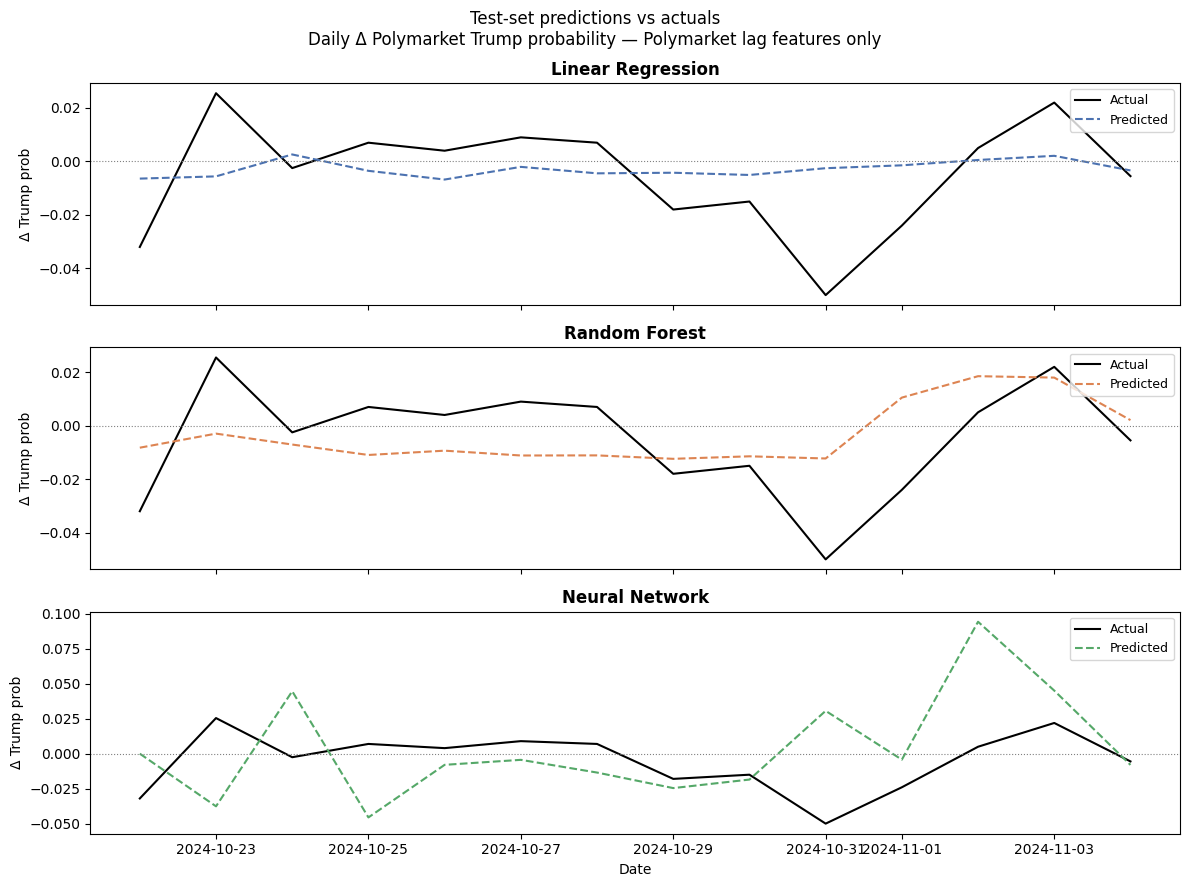

In [15]:
# Predictions vs actuals on the test set
test_dates = df_test['date'].values
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, (label, pred, col) in zip(axes, [
    ('Linear Regression', lr_pred, colors[0]),
    ('Random Forest',     rf_pred, colors[1]),
    ('Neural Network',    nn_pred, colors[2]),
]):
    ax.plot(test_dates, y_test, label='Actual',    color='black', linewidth=1.5)
    ax.plot(test_dates, pred,   label='Predicted', color=col,    linewidth=1.5, linestyle='--')
    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel('Δ Trump prob')
    ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Date')
fig.suptitle('Test-set predictions vs actuals\nDaily Δ Polymarket Trump probability — Polymarket lag features only',
             fontsize=12)
plt.tight_layout()
plt.show()

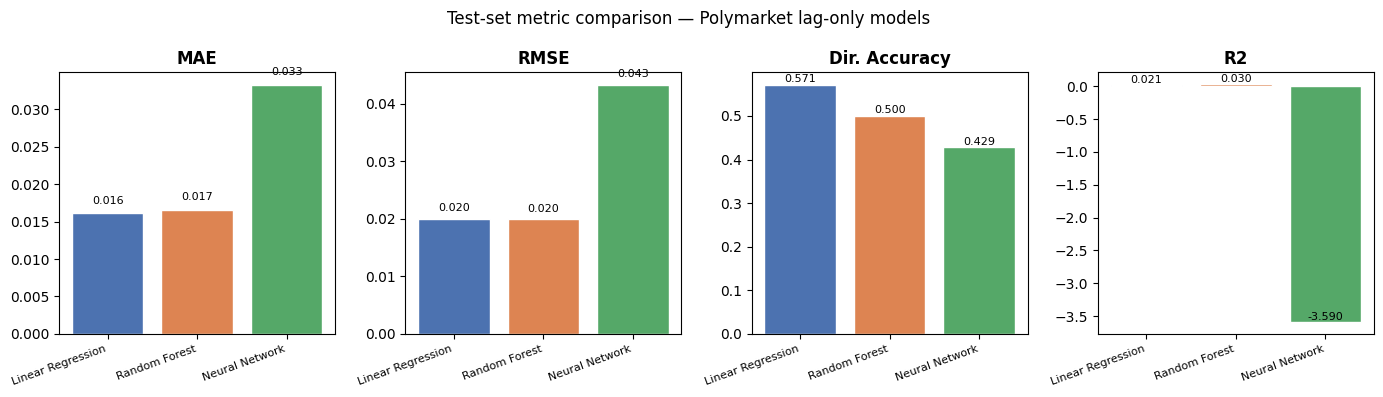

In [16]:
# Bar-chart comparison of test metrics
metrics = ['MAE', 'RMSE', 'Dir. Accuracy', 'R2']
models  = ['Linear Regression', 'Random Forest', 'Neural Network']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, metric in zip(axes, metrics):
    vals = [test_summary.loc[m, metric] for m in models]
    bars = ax.bar(models, vals, color=colors, edgecolor='white')
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8
        )

fig.suptitle('Test-set metric comparison — Polymarket lag-only models', fontsize=12)
plt.tight_layout()
plt.show()